# TOPP-HATT

Given some tree, restrict the node and leaf choices of HATT to find the minimum pauli-weight and weighted-pauli-weight tree.

# Setup

In [6]:
# Import coefficients
import pickle
from ferrmion.encode import TernaryTree
from pathlib import Path

def water_integrals():
    folder = Path.cwd().joinpath(Path("../../../python/tests/"))
    with open(folder.joinpath("./data/water_1e.pkl"), 'rb') as file:
        ones = pickle.load(file)

    with open(folder.joinpath("./data/water_2e.pkl"), 'rb') as file:
        twos = pickle.load(file)
    return (ones, twos)
ones, twos = water_integrals()
twos *= 0.5

In [7]:
from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.encode import TernaryTree, JordanWigner, ParityEncoding, BravyiKitaev, JKMN
from ferrmion.encode.ternary_tree_node import TTNode
from ferrmion.visualise import draw_tt, symplectic_matshow
import numpy as np
import logging
logger = logging.getLogger(__name__)
# from openfermion.chem.pubchem import geometry_from_pubchem
# from openfermion.chem.molecular_data import MolecularData
# from openfermion.chem.molecular_data import spinorb_from_spatial
# import openfermionpyscf
# import openfermion
# geometry=geometry_from_pubchem("H2O")
# mol = MolecularData(geometry=geometry, basis="sto-3g", multiplicity=1)
# mol = openfermionpyscf.run_pyscf(molecule=mol, run_scf=True)
# ones, twos = spinorb_from_spatial(mol.one_body_integrals, mol.two_body_integrals)

In [8]:
def pauli_weights(pauli_hamiltonian: dict[str, float]) -> list[float]:
    unscaled_terms = []
    scaled_terms = []
    for k, v in pauli_hamiltonian.items():
        assert v != 0
        pw = (len(k) - k.count("I")) 
        unscaled_terms.append(pw)
        scaled_terms.append(pw* np.abs(v))

    return (unscaled_terms, scaled_terms, len(pauli_hamiltonian))

from ferrmion.hamiltonians import fill_template, molecular_hamiltonian_template
def fill_template_find_norms(template, ones, twos, permutation):
    permutation = np.array(permutation, dtype=np.uint)
    ham = fill_template(template, 0, ones, twos, permutation)
    
    return pauli_weights(ham)

# POC: Jordan-Wigner

For JW we enforce that we start with the node farthest from the root, then each subsequent node is attached as the Z-parent of the previous.

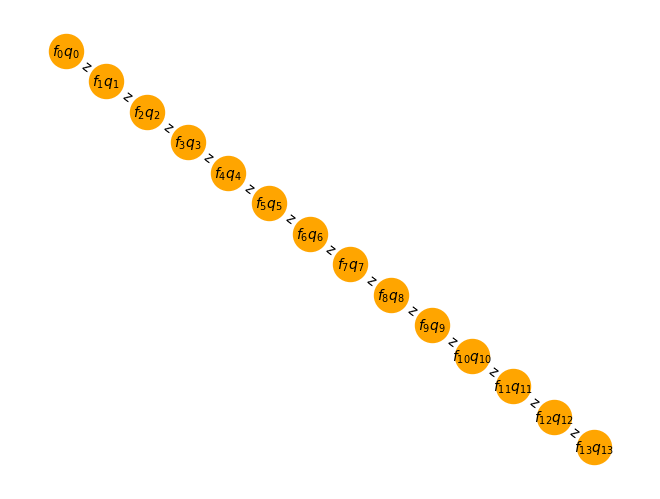

In [5]:
from ferrmion.encode import JordanWigner
from ferrmion.visualise import draw_tt
base_jw = JordanWigner(14)
draw_tt(base_jw, enumeration_scheme=base_jw.default_enumeration_scheme(), type="linear")

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def symplectic_matshow(symplectics, title: str | None = None):
    """Colorised Matplolibn.matshow of a symplectic array."""
    # Crear el mapa de colores cualitativo
    colors = ["linen", "tab:red", "tab:blue", "tab:purple"]

    left, right = np.hsplit(symplectics, 2)
    symplectics = (left + 2 * right) % 4

    # For cases where there is no Y or Z, the colormap must be scaled down.
    cmap = ListedColormap(colors[: np.max(symplectics) + 1])
    fig = plt.figure(figsize=(5,5))
    ax = fig.add_subplot(111)
    ax.matshow(symplectics, cmap=cmap, alpha=0.8)
    handles = [plt.Line2D([0], [0], color=color, lw=4) for color in colors]
    labels = ["I", "X", "Z", "Y"]
    ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=4)
    if title is not None:
        plt.title(title)
    ax.set_xlabel("Qubit")
    ax.tick_params(labeltop=False, labelbottom=True)
    ax.set_ylabel(r"Majorana $\gamma$")
    ax.set_yticks(range(symplectics.shape[0]))


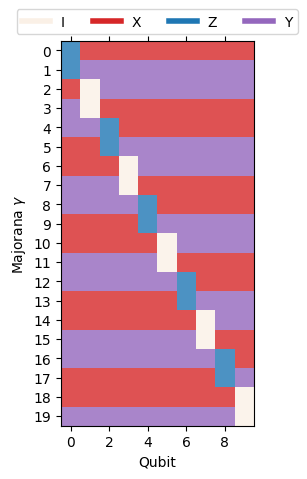

In [7]:
from ferrmion.utils import check_trivial_overlap
from ferrmion.encode import MaxNTO

sym = MaxNTO(10)._build_symplectic_matrix()[1]

symplectic_matshow(sym)


[[0. 1. 1. 1. 1. 1. 1. 1.]
 [1. 0. 1. 1. 1. 1. 1. 1.]
 [1. 1. 0. 1. 1. 1. 1. 1.]
 [1. 1. 1. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 1. 1. 1.]
 [1. 1. 1. 1. 1. 0. 1. 1.]
 [1. 1. 1. 1. 1. 1. 0. 1.]
 [1. 1. 1. 1. 1. 1. 1. 0.]]


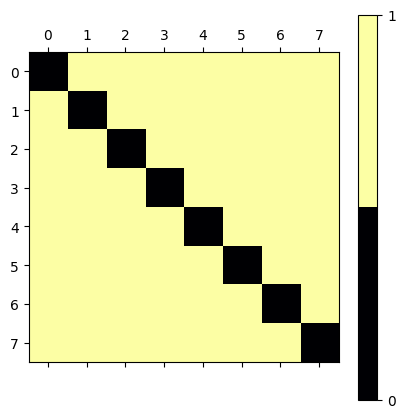

In [8]:
from ferrmion.utils import check_trivial_overlap
import matplotlib.pyplot as plt
from ferrmion.encode import MaxNTO

ntos = check_trivial_overlap(JordanWigner(4)._build_symplectic_matrix()[1])[1]
print(ntos)
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111)
cmap=plt.get_cmap("inferno", int(np.max(ntos)- np.min(ntos) +1))
cax = ax.matshow(ntos, cmap=cmap)
fig.colorbar(cax, ticks = [0,1], spacing="proportional")

[[0. 9. 9. 1. 3. 9. 7. 3. 5. 7. 5. 5. 7. 5. 3. 7. 9. 3. 1. 9.]
 [9. 0. 1. 9. 9. 3. 3. 7. 7. 5. 5. 5. 5. 7. 7. 3. 3. 9. 9. 1.]
 [9. 1. 0. 9. 9. 1. 1. 7. 7. 3. 3. 5. 5. 5. 5. 3. 3. 7. 7. 1.]
 [1. 9. 9. 0. 1. 9. 7. 1. 3. 7. 5. 3. 5. 5. 3. 5. 7. 3. 1. 7.]
 [3. 9. 9. 1. 0. 9. 9. 1. 3. 9. 7. 3. 5. 7. 5. 5. 7. 5. 3. 7.]
 [9. 3. 1. 9. 9. 0. 1. 9. 9. 3. 3. 7. 7. 5. 5. 5. 5. 7. 7. 3.]
 [7. 3. 1. 7. 9. 1. 0. 9. 9. 1. 1. 7. 7. 3. 3. 5. 5. 5. 5. 3.]
 [3. 7. 7. 1. 1. 9. 9. 0. 1. 9. 7. 1. 3. 7. 5. 3. 5. 5. 3. 5.]
 [5. 7. 7. 3. 3. 9. 9. 1. 0. 9. 9. 1. 3. 9. 7. 3. 5. 7. 5. 5.]
 [7. 5. 3. 7. 9. 3. 1. 9. 9. 0. 1. 9. 9. 3. 3. 7. 7. 5. 5. 5.]
 [5. 5. 3. 5. 7. 3. 1. 7. 9. 1. 0. 9. 9. 1. 1. 7. 7. 3. 3. 5.]
 [5. 5. 5. 3. 3. 7. 7. 1. 1. 9. 9. 0. 1. 9. 7. 1. 3. 7. 5. 3.]
 [7. 5. 5. 5. 5. 7. 7. 3. 3. 9. 9. 1. 0. 9. 9. 1. 3. 9. 7. 3.]
 [5. 7. 5. 5. 7. 5. 3. 7. 9. 3. 1. 9. 9. 0. 1. 9. 9. 3. 3. 7.]
 [3. 7. 5. 3. 5. 5. 3. 5. 7. 3. 1. 7. 9. 1. 0. 9. 9. 1. 1. 7.]
 [7. 3. 3. 5. 5. 5. 5. 3. 3. 7. 7. 1. 1. 9. 9. 0. 1. 9.

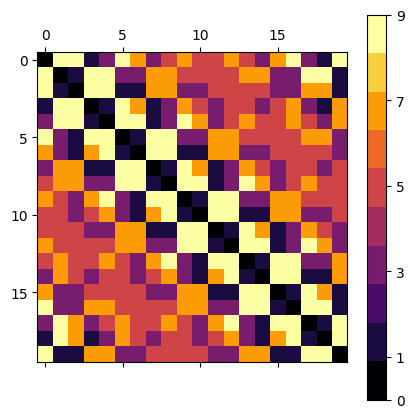

In [9]:
from ferrmion.utils import check_trivial_overlap
import matplotlib.pyplot as plt
from ferrmion.encode import MaxNTO

ntos = check_trivial_overlap(MaxNTO(10)._build_symplectic_matrix()[1])[1]
print(ntos)
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111)
cmap=plt.get_cmap("inferno", 10)
cax = ax.matshow(ntos, cmap=cmap)
fig.colorbar(cax, ticks = [0,*range(1, int(np.max(ntos)+2),2)], spacing="uniform")

In [10]:
def pauli_weights(pauli_hamiltonian: dict[str, float]) -> list[float]:
    unscaled_terms = []
    scaled_terms = []
    for k, v in pauli_hamiltonian.items():
        assert v != 0
        pw = (len(k) - k.count("I")) 
        unscaled_terms.append(pw)
        scaled_terms.append(pw* np.abs(v))

    return (unscaled_terms, scaled_terms, len(pauli_hamiltonian))

from ferrmion.hamiltonians import fill_template, molecular_hamiltonian_template
def fill_template_find_norms(template, ones, twos, permutation):
    permutation = np.array(permutation, dtype=np.uint)
    ham = fill_template(template, 0, ones, twos, permutation)
    
    return pauli_weights(ham)

# TOPP-HATT

## Defining Restrictions

All Z-node
- Z-majorana must be 2n

Terminal nodes
- no restrictions, x,y,z majoranas can be any number.

Z-Parents
- Z-child must be retained

X-Parents
- X-child must be retained
- x-majorana of parent is z-leaf of X-child's z-decendant

Y-Parents
- Y-child must be retained
- y-majorana of parent is z-leaf of Y-child's z-decendant



## Initialise the restrictions

We should be able to set all of these exactly, as we know the structure of the tree ahead of time.

In [ ]:
from ferrmion.encode.ternary_tree_node import TTNode
def get_node(root_node: TTNode, child_string: str):
    node = root_node
    for char in child_string:
        node = getattr(node, char)
    return node

def add_all_z_restriction(tree,string_index_map, restrictions):
    child_strings = tree.root_node.child_strings
    all_z = sorted({child for child in child_strings if "x" not in child and "y" not in child}, key=len, reverse=True)[0]
    all_z_index = string_index_map[all_z]
    restrictions[all_z_index][2] = 2*tree.n_modes
    return restrictions

def majorana_indices_of_node(node_index, n_leaves) -> int:
    x_majorana = 2*(node_index - n_leaves)
    y_majorana = x_majorana+1
    return x_majorana, y_majorana

def get_twinned_majorana_index(node: TTNode):
    index = node.leaf_majorana_indices["z"]
    if index is None:
        return None
    if index %2 == 0:
        return index + 1
    else:
        return index - 1


def add_retain_child_restrictions(tree:TernaryTree, string_index_map, restrictions):
    """Nodes that have a child."""
    child_strings = tree.root_node.child_strings
    for node in child_strings:
        if node == "":
            continue
        parent = node[:-1]
        parent_index = string_index_map[parent]
        node_index = string_index_map[node]
        match node[-1]:
            case "x":
                restrictions[parent_index][0] = node_index
            case "y":
                restrictions[parent_index][1] = node_index
            case "z":
                restrictions[parent_index][2] = node_index
    return restrictions

def add_xy_parent_restrictions(
        tree:TernaryTree, 
        string_index_map:dict[str,int], 
        node_objects_map:dict[int, TTNode],
        restrictions:dict[int, list[int|None]]
        ):
    """Nodes that have an X-parent or Y-parent."""
    child_strings = tree.root_node.child_strings
    parent_strings = {child[:-1] for child in child_strings}
    n_leaves = 2*tree.n_modes
    for child in child_strings:
        child_index = string_index_map[child]
        child_node = node_objects_map[child_index]
        #child can be it's own ancestor
        ancestor= child_node.z_ancestor

        if ancestor.root_path == "":
            continue
        # Z-ancestors of an x-child have even z-leaf
        if ancestor.root_path[-1] == "x":
            restrictions[child_index][2] = "Even"
        # Z-ancestors of an y-child have odd z-leaf
        elif ancestor.root_path[-1]=="y":
            restrictions[child_index][2] = "Odd"

    return restrictions

def get_string_index_map(tree):
    n_leaves = 2*tree.n_modes+1
    enumeration_scheme = tree.default_enumeration_scheme()
    child_strings = tree.root_node.child_strings
    return {child: n_leaves+enumeration_scheme[child][1] for child in child_strings}

def get_node_objects_map(tree, string_index_map):
    return {string_index_map[child]: get_node(tree.root_node, child) for child in tree.root_node.child_strings}

def initialise_restrictions(tree:TernaryTree):
    string_index_map = get_string_index_map(tree)
    node_objects_map = get_node_objects_map(tree, string_index_map)
    for node in node_objects_map.values():
        node.leaf_majorana_indices = {"x":None,"y":None,"z":None}

    # each node has restrictions in tuple (restrictions on x, restrictions on y, restrictions on z)
    restrictions = {i: ["Any", "Any", "Any"] for i in string_index_map.values()}
    restrictions = add_xy_parent_restrictions(tree, string_index_map, node_objects_map, restrictions)
    restrictions = add_retain_child_restrictions(tree, string_index_map, restrictions)
    restrictions = add_all_z_restriction(tree,string_index_map, restrictions)
    return restrictions

In [ ]:
def unpack_single_restriction(restriction: str|int, unassigned_leaves:set):
    match restriction:
        case "Any":
            restriction = unassigned_leaves
        case "Even":
            restriction = [i for i in unassigned_leaves if i%2 ==0]
        case "Odd":
            restriction = [i for i in unassigned_leaves if i%2 ==1]
        # a REQUIRED assignment will be removed from unassigned_leaves
        case int():
            restriction = [restriction]
        case _:
            raise ValueError("Restriction should be 'Any', 'Even', 'Odd' or int.")
    return restriction

def update_restrictions(restrictions, parent_node, string_index_map):
    # The node may be its own z-ancestor
    restrictor = parent_node.z_ancestor
    logger.debug(f"{restrictor=}")

    logger.debug(f"{restrictions=}")
    if restrictor.root_path == "":
        pass
    elif restrictor.root_path[-1]=="x":
        if isinstance(restrictor.parent.y,TTNode):
            restricted = restrictor.parent.y.z_descendant
            logger.debug(f"{restricted=}")
            restrictions[string_index_map[restricted.root_path]][2] = restrictor.z_descendant.leaf_majorana_indices["z"] +1
        elif restrictor.parent.y is None:
            restricted = restrictor.parent
            logger.debug(f"{restricted=}")
            restrictions[string_index_map[restricted.root_path]][1] = restrictor.z_descendant.leaf_majorana_indices["z"] +1

            
    elif restrictor.root_path[-1]=="y":
        if isinstance(restrictor.parent.x,TTNode):
            restricted = restrictor.parent.x.z_descendant
            logger.debug(f"{restricted=}")
            restrictions[string_index_map[restricted.root_path]][2] = restrictor.z_descendant.leaf_majorana_indices["z"] -1
        elif restrictor.parent.x is None:
            restricted = restrictor.parent
            logger.debug(f"{restricted=}")
            restrictions[string_index_map[restricted.root_path]][0] = restrictor.z_descendant.leaf_majorana_indices["z"] -1
    logger.debug(f"{restrictions=}")
    return restrictions 
        

In [ ]:
from ferrmion.encode import BK, ParityEncoding, JordanWigner
def initialise_node_dependencies(tree:TernaryTree):
    string_index_map = get_string_index_map(tree)
    child_strings = tree.root_node.child_strings
    dependencies = {string_index_map[child]:[] for child in child_strings}

    for child in child_strings:
        for char in ["x","y","z"]:
            if child+char in child_strings:
                dependencies[string_index_map[child]].append(string_index_map[child+char])
    return dependencies

initialise_node_dependencies(BK(4))

In [ ]:
def initialise_active_nodes(index_string_map, node_dependencies):
    active_nodes:dict[int,set[TTNode]] = {}
    for node_index, deps in node_dependencies.items():
        root_len = len(index_string_map[node_index])
        if deps != []:
            continue
        if active_nodes.get(root_len, None) is None:
            active_nodes[root_len] = set()
        active_nodes[root_len].add(node_index)
    return active_nodes


def update_active_nodes(active_nodes, min_parent, index_string_map, node_dependencies, completed_nodes):
    active_nodes[root_len:= len(index_string_map[min_parent])].remove(min_parent)
    if active_nodes[root_len] == set():
        active_nodes.pop(root_len)

    for node,deps in node_dependencies.items():
        if completed_nodes.issuperset(deps):
            root_len =len(index_string_map[node])
            if active_nodes.get(root_len, None) is None:
                active_nodes[root_len] = set()
            active_nodes[root_len].add(node)
    return active_nodes

In [ ]:
from ferrmion.encode import TernaryTree
from itertools import product
from typing import Iterable
import logging 
from ferrmion.optimize.hatt import _reduce_hamiltonian

logger = logging.getLogger(__name__)

def build_valid_combination(comb: tuple[int,int], 
                      descendant_map:dict, 
                      ancestor_map:dict, 
                      n_modes:int, 
                      selection:list[int,int,int], 
                      ) -> None|list[int,int,int]:
    # logging.debug(f"{comb=}")
    z_index, x_index = comb
    if z_index == x_index:
        return None

    small_y = None
    small_x = None

    small_x = descendant_map[x_index]

    # discard this combination
    if small_x == 2 * n_modes:
        return None

    if small_x % 2 == 0:
        small_y = small_x + 1
    else:
        small_y = small_x - 1
    # We can't use this index for y a
    # it has been used in the combination already
    # so we'd be replacing our x or z!
    if small_y in comb:
        return None

    y_index = ancestor_map[small_y]

    if y_index in comb:
        return None

    if small_x % 2 == 0:
        comb = [x_index, y_index, z_index]
    else:
        comb = [y_index, x_index, z_index]

    # W3 can end uop with the same combination in two different ways
    if comb == selection:
        return None
    return comb


In [ ]:
def topp_hatt(
    majorana_ham: dict[Iterable[int], float],
    tree: TernaryTree,
    coeff_weight:bool=False,
) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # if coeff_weight:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0])*item[1], reverse=True)}
    # else:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0]), reverse=True)}
    n_modes = tree.n_modes
    n_leaves = 2*n_modes +1
    # We need 2*M +1 leaves and M nodes.
    nodes: dict[int, TTNode | None] = {i: None for i in range(n_leaves-1)}
    node_dependencies = initialise_node_dependencies(tree)
    logging.debug(f"Initial Dependencies:\n{node_dependencies}")

    string_index_map = get_string_index_map(tree)
    index_string_map = {v:k for k,v in string_index_map.items()}
    
    node_objects_map = get_node_objects_map(tree, string_index_map)

    for node in node_objects_map.values():
        for char in ["x","y","z"]:
            node.branch_majorana_map[char] = None

    nodes.update(get_node_objects_map(tree, string_index_map))
    
    
    active_nodes:dict[int,set[TTNode]] = initialise_active_nodes(index_string_map=index_string_map, node_dependencies=node_dependencies)


    # active_nodes:set[int] = {node for node, deps in node_dependencies.items() if deps == []}
    completed_nodes = set()
    restrictions = initialise_restrictions(tree)

    logger.debug(f"Initial Restrictions:\n{restrictions}")
    # Start with all the leaves unassigned
    unassigned_leaves = [*range(n_leaves)]
    unassigned_leaves.reverse()

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i: i for i in range(n_leaves + n_modes)}
    descendant_map = {i: i for i in range(n_leaves  + n_modes)}

    total_weight = 0
    for i in range(n_modes+1):
        logging.debug(f"\nLoop {i}")
        # # Update the restrictions with the new information about the tree.
        # # Any nodes that are required to be in a certain position 
        # # have to be removed from unassigned!
        to_remove = []
        for restriction in restrictions.values():
            for term in restriction:
                if isinstance(term, int):
                    to_remove.append(term)
        unassigned_leaves = [l for l in unassigned_leaves if l not in to_remove]
        logger.debug(f"{unassigned_leaves=}")

        min_weight = np.inf
        min_parent = None
        selection = [None, None, None]
        
        # NOTE
        # Another opion would be to check all allowed
        # combinations just once and then to look 
        # for the parent that is eligable for the minimum combination.
        logging.debug(f"{active_nodes=}")
        max_len_active = active_nodes[max([*active_nodes.keys()])]
        logging.debug(f"{max_len_active=}")
        unique_restrictions = set()
        for parent_index in max_len_active:
            logging.debug(f"\n{parent_index=}")


            # Z-child of new node will always be the previous node.
            # We only need to use every second entry in unassigned
            # as we already order odd/even terms
            # we also know for jw that every new node will be
            # the z-ancestor all all other nodes.

            parent_restrictions = restrictions[parent_index]
            if tuple(parent_restrictions) in unique_restrictions:
                continue
            else:
                unique_restrictions.add(tuple(parent_restrictions))
            logger.debug(f"{unique_restrictions=}")

            allowed_x = unpack_single_restriction(parent_restrictions[0], unassigned_leaves)
            allowed_y = unpack_single_restriction(parent_restrictions[1], unassigned_leaves)
            allowed_z = unpack_single_restriction(parent_restrictions[2], unassigned_leaves)
            logger.debug(f"{allowed_x=}")
            logger.debug(f"{allowed_y=}")
            logger.debug(f"{allowed_z=}")

            match parent_restrictions[0], parent_restrictions[1]:
                case ("Any", "Any"):
                    allowed_product = product(allowed_z, allowed_x)
                case (x, "Any") if x != "Any":
                    allowed_product = product(allowed_z, allowed_x)
                case ("Any", y) if y != "Any":
                    allowed_product = product(allowed_z, allowed_y)
                case (x, y) if "Any" not in [x,y]:
                    allowed_product = product(allowed_x, allowed_y, allowed_z)

            # If x and y are both none, just do all x and create a pair
            # if x is none and y is set, just use y
            # if x is set and y is none, just use x

            logging.debug(f"{parent_restrictions=}")
            for comb in allowed_product:
                match len(comb):
                    case 2:
                        comb = build_valid_combination(comb, descendant_map, ancestor_map, n_modes, selection)
                        if comb is None:
                            continue
                    case 3:
                        # We can use the combination provided
                        comb = list(comb)
                    case _:
                        raise ValueError("Length of combination should be 2 or 3.")

                weight = 0
                for key in majorana_ham.keys():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        if weight > min_weight:
                            break
                        print(f"{comb=}")
                        print(f"Term {key}")
                        print(f"{weight=}")

                if weight < min_weight:
                    logging.debug(f"NEW Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                    min_weight = weight
                    selection = comb
                    min_parent = parent_index
                # elif weight == min_weight:
                # #     # logging.debug(f"SAME Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                    # min_weight = weight
                    # selection = comb 
                    # min_parent = parent_index
            logging.debug(f"{parent_index=}, {selection=}")
        total_weight += min_weight

        logging.debug(f"{min_parent=}")
        # Now find the Y pair of the x-node
        unassigned_leaves = [ u for u in unassigned_leaves if u not in selection]
        for child_index, char in zip(selection, ["x", "y", "z"]):
            maybe_node = node_objects_map.get(child_index, None)
            if isinstance(maybe_node, TTNode):
                continue
            node_objects_map[min_parent].leaf_majorana_indices[char] = child_index
        
        if i +1 == n_modes:
            break

        logging.debug(f"Loop: {i}, Selection: {selection}, Chosen Parent: {min_parent},{index_string_map[min_parent]}")
        
        completed_nodes.add(min_parent)
        node_dependencies.pop(min_parent)
 
        active_nodes = update_active_nodes(active_nodes=active_nodes, min_parent=min_parent, index_string_map=index_string_map, node_dependencies=node_dependencies, completed_nodes=completed_nodes)

        z_index = selection[2]

        # Update the restrictions on the parent node to be its selection.
        restrictions[min_parent] = selection
        # Use these to update restrictions on other nodes.

        parent_node = node_objects_map[min_parent]
        restrictions = update_restrictions(restrictions, parent_node=parent_node, string_index_map=string_index_map)
        
        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index

        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)

    if len(active_nodes) != 1:
        raise ValueError(f"Not all nodes assigned by HATT. {active_nodes=}")

    tree.pauli_weight = total_weight
    return tree

In [ ]:
# from ferrmion.optimize import topphatt
for encoding in [JordanWigner]:
    tree= topp_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), tree=encoding(14))
    print(tree.pauli_weight)
    tree._build_symplectic_matrix()

# Compare Naive, HATT and Simulated Annealing

In [9]:
from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.core import anneal_enumerations
from ferrmion.core import topphatt_standard as topphatt_core   
from ferrmion.core import encode_standard 
from ferrmion.optimize import topphatt 
from ferrmion.encode import TernaryTree
from ferrmion.hamiltonians import molecular_hamiltonian_template
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from copy import deepcopy
# Import coefficients
import pickle
from ferrmion.encode import TernaryTree
from pathlib import Path

def water_integrals():
    folder = Path.cwd().joinpath(Path("../../../python/tests/"))
    with open(folder.joinpath("./data/water_1e.pkl"), 'rb') as file:
        ones = pickle.load(file)

    with open(folder.joinpath("./data/water_2e.pkl"), 'rb') as file:
        twos = pickle.load(file)
    return (ones, twos)
ones, twos = water_integrals()
twos *= 0.5

sparse_ham = fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--")))

# topphatt = topp_hatt

def get_topp_hatt_results(tree: TernaryTree, name:str, limit=1000):
    print("Getting Naive result...")
    sdmeans_naive = {}
    rng = np.random.RandomState(1017)
    
    sym = tree._build_symplectic_matrix()
    template = molecular_hamiltonian_template(*sym, physicist_notation=True)
    result = fill_template_find_norms(template, ones, twos, np.array([*range(ones.shape[0])], dtype=np.uint))
    # filled_template = encode_standard(encoding=name, n_modes=14, n_qubits=14, signatures=["+-","++--"], coeffs=[ones,twos], mode_op_map=None)
    # result=pauli_weights(filled_template)
    sdmeans_naive["unscaled"] = np.mean(result[0])
    sdmeans_naive["scaled"] = np.mean(result[1])
    sdmeans_naive["length"] = result[2]

    print(f"Getting {limit} random results...")
    sdmeans = {}
    sdmeans = {"unscaled":[], "scaled":[], "length":[]}
    i=0
    while i < limit:
        perm = rng.permutation(ones.shape[0])
        result = fill_template_find_norms(template, ones, twos, perm) 
        # filled_template = encode_standard(encoding=name, n_modes=14, n_qubits=14, signatures=["+-","++--"], coeffs=[ones,twos], mode_op_map=perm)
        # result=pauli_weights(filled_template)
        sdmeans["unscaled"].append(np.mean(result[0])) 
        sdmeans["scaled"].append(np.mean(result[1]))
        sdmeans["length"].append(result[2])
        i+=1

    print("Getting Annealed result...")
    sdmeans_annealed = {}
    annealed_best = anneal_enumerations(template, ones, twos, temperature=ones.shape[0], initial_guess=np.array([*range(ones.shape[0])],dtype=np.uint), coefficient_weighted=False)
    result = fill_template_find_norms(template, ones, twos, annealed_best[1])
    sdmeans_annealed["unscaled"] = np.mean(result[0])
    sdmeans_annealed["scaled"] = np.mean(result[1])
    sdmeans_annealed["length"] = result[2]
    sdmeans_annealed

    print("Running TOPP-HATT...")
    # sym = topphatt_core(encoding=name, n_modes=14, n_qubits=14, signatures=["+-","++--"], coeffs=[ones,twos])
    # result=pauli_weights(filled_template)
    topphatt_tree = topphatt(majorana_ham=deepcopy(sparse_ham), tree=tree)
    sym = topphatt_tree._build_symplectic_matrix()
    # print(f"TOPPHATT weight {hatt_tree.pauli_weight}")
    print("Getting TOPP-HATT result...")
    template = molecular_hamiltonian_template(*sym, physicist_notation=True)
    result = fill_template_find_norms(template, ones, twos, [*range(14)])
    sdmeans_topphatt = {}
    sdmeans_topphatt["unscaled"] = np.mean(result[0])
    sdmeans_topphatt["scaled"] = np.mean(result[1])
    sdmeans_topphatt["length"] = result[2]

    if name in ["JW", "BK","PE","JKMN"]:
        print("Running TOPP-HATT CORE...")
        ipowsym = topphatt_core(encoding=name, n_modes=14, n_qubits=14, signatures=["+-","++--"], coeffs=[deepcopy(ones),deepcopy(twos)])
        template = molecular_hamiltonian_template(*ipowsym, physicist_notation=True)
        # result=pauli_weights(filled_template)
        # hatt_tree = topphatt(majorana_ham=deepcopy(sparse_ham), tree=tree)
        # print(f"topphatt_core weight {hatt_tree.pauli_weight}")
        print("Getting TOPP-HATT result...")
        # template = molecular_hamiltonian_template(*hatt_tree._build_symplectic_matrix(), physicist_notation=True)
        result = fill_template_find_norms(template, ones, twos, [*range(14)])
        sdmeans_topphatt_core = {}
        sdmeans_topphatt_core["unscaled"] = np.mean(result[0])
        sdmeans_topphatt_core["scaled"] = np.mean(result[1])
        sdmeans_topphatt_core["length"] = result[2]



    color_set = {"jw":"tab:blue", "pe":"tab:orange", "bk":"tab:green", "jkmn":"tab:red", "bonsai":"tab:purple", "huffman":"tab:brown", "hatt":"tab:pink"}
    fig, ax = plt.subplots(layout="constrained")

    ax.scatter(sdmeans["unscaled"], sdmeans["scaled"], label="Randomised Permutations", marker=".", color="tab:grey", alpha=0.7)
    ax.plot(sdmeans_naive["unscaled"], sdmeans_naive["scaled"], marker="D", color="tab:red", mec="k", markersize=8)
    ax.plot(sdmeans_annealed["unscaled"], sdmeans_annealed["scaled"], marker="o", color="tab:orange", mec="k", markersize=8)
    ax.plot(sdmeans_topphatt["unscaled"], sdmeans_topphatt["scaled"], marker="P", color="tab:green", mec="k", markersize=8)
    
    if name in ["JW", "BK","PE","JKMN"]:
        ax.plot(sdmeans_topphatt_core["unscaled"], sdmeans_topphatt["scaled"], marker="P", color="tab:grey", mec="k", markersize=8)



    # where some data has already been plotted to ax
    handles, labels = plt.gca().get_legend_handles_labels()
    # manually define a new patch 
    naive_legend = mlines.Line2D([], [], label='Naive Enumeration', marker="D", linestyle="", color="tab:red", mec="k", markersize=8)
    annealed_legend = mlines.Line2D([], [], label='Annealed Best', marker="o", linestyle="",color="tab:orange", mec="k", markersize=8)
    topphatt_legend = mlines.Line2D([], [], label='TOPP-HATT', marker="P", linestyle="",color="tab:green", mec="k", markersize=8)

    # handles is a list, so append manual patch
    handles.extend([
        naive_legend, 
                    annealed_legend, 
                    topphatt_legend
                    ])

    ax.set_xlabel("unscaled pauli-weight")
    ax.set_ylabel("coefficient scaled pauli-weight")
    ax.set_title(f"{name} Encodings of $H_2 O$:$STO-3G$")
    fig.legend(handles=handles, loc="outside lower center", ncols=len(handles)//2)
    fig.show()

## Standard Encodings

Getting Naive result...
Getting 1000 random results...
Getting Annealed result...
Running TOPP-HATT...
Getting TOPP-HATT result...
Running TOPP-HATT CORE...
Getting TOPP-HATT result...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_20074/344850360.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


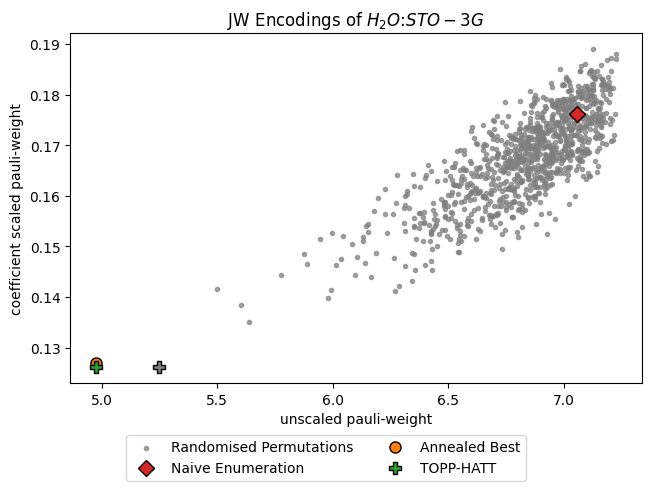

In [10]:
from ferrmion.encode import JordanWigner
get_topp_hatt_results(JordanWigner(14), "JW")

Getting Naive result...
Getting 1000 random results...
Getting Annealed result...
Running TOPP-HATT...
Getting TOPP-HATT result...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_20074/344850360.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


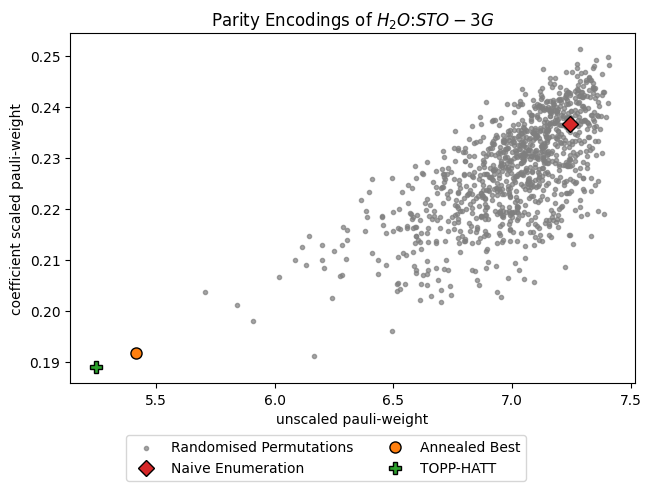

In [11]:
from ferrmion.encode import ParityEncoding
get_topp_hatt_results(ParityEncoding(14), name="Parity")

Getting Naive result...
Getting 1000 random results...
Getting Annealed result...
Running TOPP-HATT...
Getting TOPP-HATT result...
Running TOPP-HATT CORE...
Getting TOPP-HATT result...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_20074/344850360.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


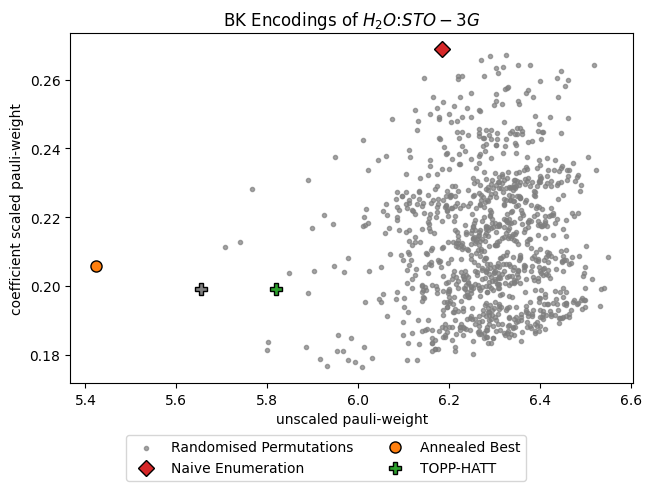

In [12]:
from ferrmion.encode import BravyiKitaev
get_topp_hatt_results(BravyiKitaev(14), name="BK")

Getting Naive result...
Getting 1000 random results...
Getting Annealed result...
Running TOPP-HATT...
Getting TOPP-HATT result...
Running TOPP-HATT CORE...
Getting TOPP-HATT result...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_20074/344850360.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


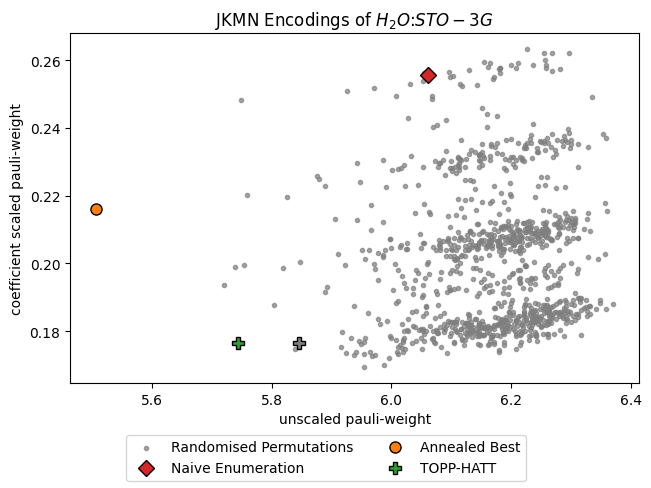

In [13]:
from ferrmion.encode import JKMN
get_topp_hatt_results(JKMN(14), name="JKMN")

## Hamiltonian Optimized Trees

In [14]:
from ferrmion.optimize import huffman_ternary_tree, topphatt
huffman_tree = huffman_ternary_tree(ones, twos)

Getting Naive result...
Getting 1000 random results...
Getting Annealed result...
Running TOPP-HATT...
Getting TOPP-HATT result...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_20074/344850360.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


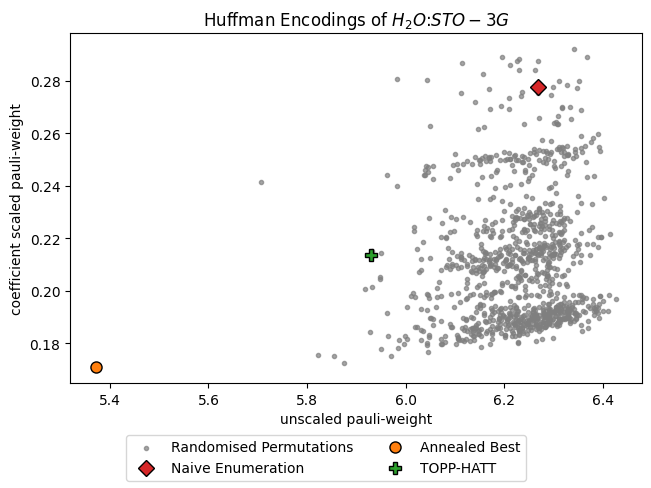

In [15]:
topphatt_huff = topphatt(deepcopy(sparse_ham), huffman_tree)
huffman_topphatt = get_topp_hatt_results(huffman_ternary_tree(ones, twos), "Huffman")

Getting Naive result...
Getting 1000 random results...
Getting Annealed result...
Running TOPP-HATT...
Getting TOPP-HATT result...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_20074/344850360.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


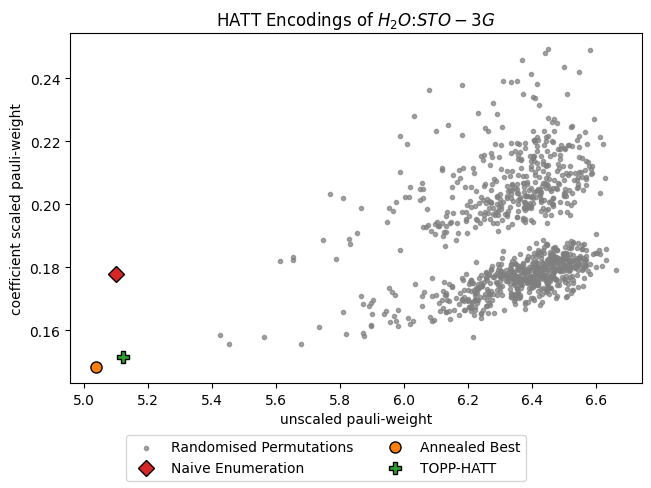

In [16]:
from ferrmion.optimize import hamiltonian_adaptive_ternary_tree
hatt_tree = hamiltonian_adaptive_ternary_tree(deepcopy(sparse_ham), 14)
get_topp_hatt_results(hatt_tree, "HATT")

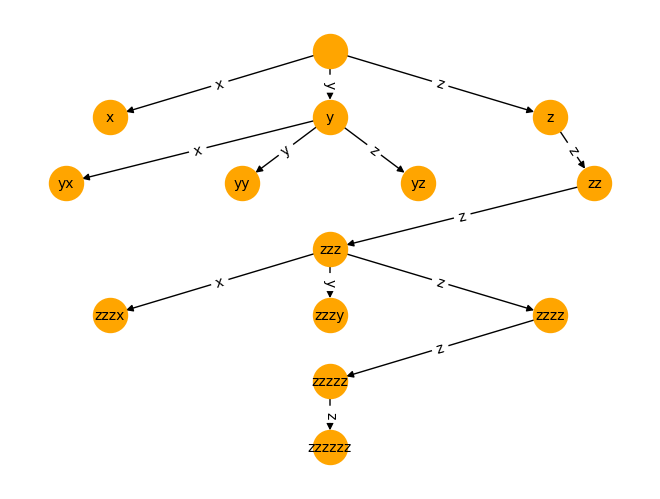

In [17]:
draw_tt(hatt_tree)

## Device Optimized Trees

In [18]:
import rustworkx as rx
from rustworkx import visualization as rxv
import matplotlib.pyplot as plt
import numpy as np
graph=rx.PyGraph()
graph.add_nodes_from(range(14))
graph.add_edges_from_no_data([(0,1),(0,2),(0,3),(1,4),(2,5),(3,6),
                              (4,7),(4,8),(5,9),(5,10),(6,11),(6,12),
                              (7,13),
                              ])

EdgeIndices[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

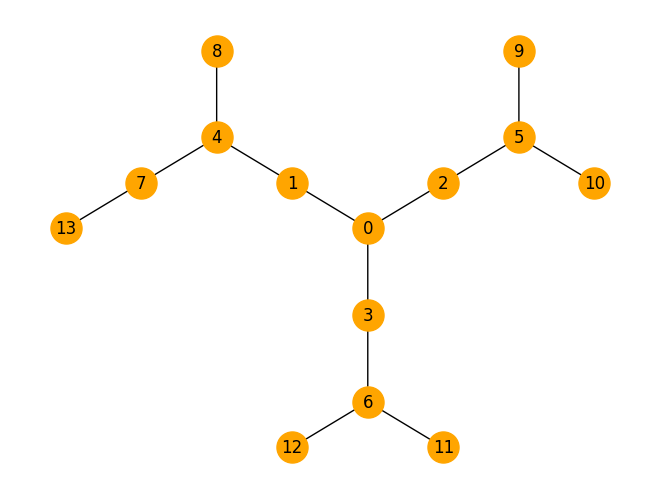

In [19]:
r = np.array([0,-1])*np.sqrt(1/graph.num_nodes())
s = np.array([1*np.sin(45),np.cos(45)])*np.sqrt(1/graph.num_nodes())
q = np.array([-1*np.sin(45),np.cos(45)])*np.sqrt(1/graph.num_nodes())
pos={0:[0,0],1:q,2:s,3:r ,4:2*q,5:2*s,
     6:2.*r,7:2*q-s,8:2*q-r,9:2*s-r,10:2*s-q,11:2*r -q,
     12:2*r -s,13:2*(q-s),
}
pos=rx.spring_layout(graph, pos=pos, fixed={*range(graph.num_nodes())})
rxv.mpl_draw(graph, with_labels=True, pos=pos, node_color="orange", node_size=500)

Getting Naive result...
Getting 1000 random results...
Getting Annealed result...
Running TOPP-HATT...
Getting TOPP-HATT result...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_20074/344850360.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


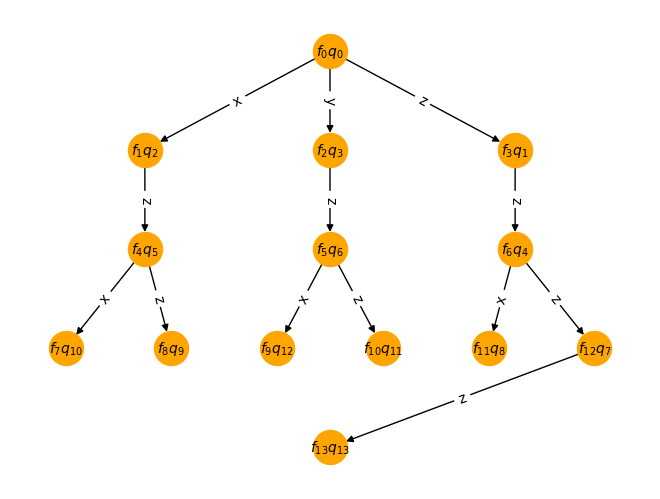

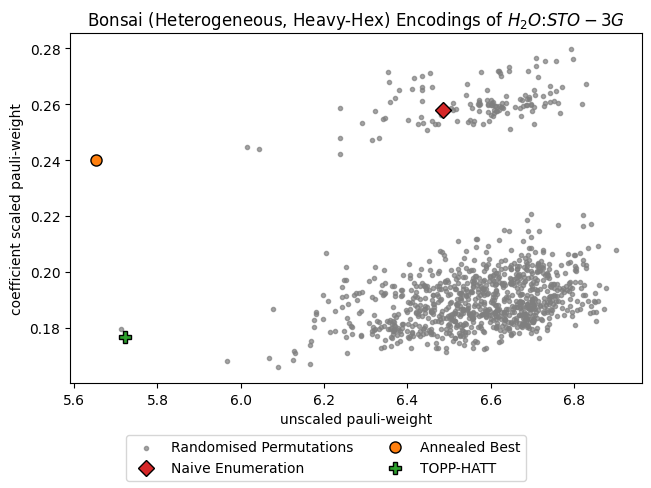

In [20]:
from ferrmion.optimize import bonsai_algorithm
bonsai= bonsai_algorithm(graph=graph, homogenous=False)
draw_tt(bonsai, type="spaced", enumeration_scheme=bonsai.default_enumeration_scheme())
bonsai.string_pairs
bonsai.as_dict()
get_topp_hatt_results(bonsai, name="Bonsai (Heterogeneous, Heavy-Hex)")

Getting Naive result...
Getting 1000 random results...
Getting Annealed result...
Running TOPP-HATT...
Getting TOPP-HATT result...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_20074/344850360.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


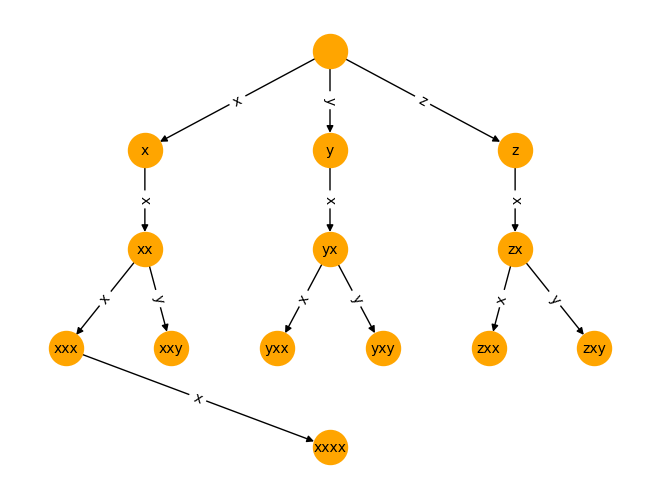

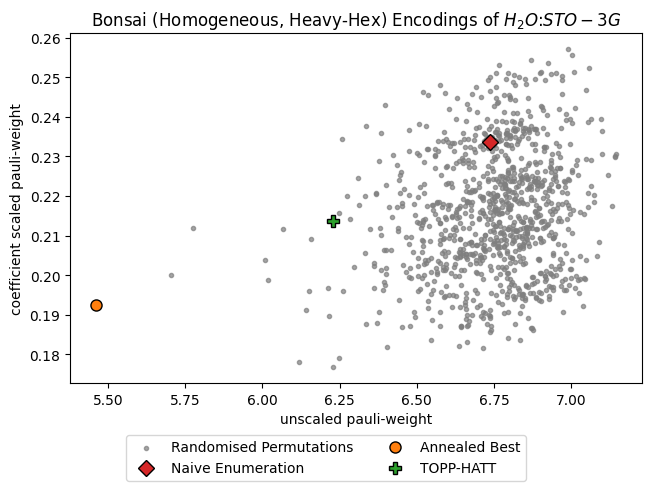

In [21]:
from ferrmion.optimize import bonsai_algorithm
bonsai= bonsai_algorithm(graph=graph, homogenous=True)
draw_tt(bonsai, type="spaced")
bonsai.string_pairs
bonsai.as_dict()
get_topp_hatt_results(bonsai, name="Bonsai (Homogeneous, Heavy-Hex)")

# Scaling

In [70]:
from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.encode import TernaryTree, JordanWigner, ParityEncoding, BravyiKitaev, JKMN
from ferrmion.encode.ternary_tree_node import TTNode
from ferrmion.visualise import draw_tt, symplectic_matshow
from ferrmion.optimize import topphatt
import numpy as np
import logging
logger = logging.getLogger(__name__)
# from openfermion.chem.pubchem import geometry_from_pubchem
# from openfermion.chem.molecular_data import MolecularData
# from openfermion.chem.molecular_data import spinorb_from_spatial
# import openfermionpyscf
# import openfermion
# geometry=geometry_from_pubchem("H2O")
# mol = MolecularData(geometry=geometry, basis="sto-3g", multiplicity=1)
# mol = openfermionpyscf.run_pyscf(molecule=mol, run_scf=True)
# ones, twos = spinorb_from_spatial(mol.one_body_integrals, mol.two_body_integrals)

In [ ]:
from openfermion.chem.pubchem import geometry_from_pubchem
from openfermion.chem.molecular_data import MolecularData
from openfermion.chem.molecular_data import spinorb_from_spatial
import openfermionpyscf
import openfermion
import timeit
import pandas as pd
from copy import deepcopy

molname = None

print(molname)
geometry=geometry_from_pubchem(molname)
print(f"got geometry {geometry}")
mol = MolecularData(geometry=geometry, basis=basis, multiplicity=1)
mol = openfermionpyscf.run_pyscf(molecule=mol, run_scf=True)
print("gettting integrals")
ones, twos = spinorb_from_spatial(mol.one_body_integrals, mol.two_body_integrals)

In [72]:
df = pd.DataFrame(columns=["molname","time", "repeats", "n_modes", "n_terms", "encoding"])

In [73]:
# timings = [t for t in timings if t["molname"]!="ethane"]

In [74]:
np.count_nonzero(ones)

np.int64(42)

In [147]:
timings = []

repeats = 1
# for molname in ["Lithium Dimer", "C2H2", "Carbon Monoxide", "BeH2","F2","BH3","BERYLLIUM OXIDE", "HCN", "ethene", "HCl","H2", "LiH", "H2O", "CH4", "N2", "O2", "formaldehyde", "CH3F", "ozone"]:
for molname in ["H2","LiH", "H2O","BH3","CH4", "N2", "HCN","C2H2", "CH3F", "ethene", "ozone"]:
# for molname in ["NOH"]:
    print(molname)
    geometry=geometry_from_pubchem(molname)
    for basis in ["sto-3g","6-31g*"]:
        print(f"got geometry {geometry}")
        mol = MolecularData(geometry=geometry, basis=basis, multiplicity=1)
        mol = openfermionpyscf.run_pyscf(molecule=mol, run_scf=True)
        print("gettting integrals")
        ones, twos = spinorb_from_spatial(mol.one_body_integrals, mol.two_body_integrals)
        # print("making sparse ham")
        # sparse_maj = fermionic_to_sparse_majorana(((ones, "+-",), (twos, "++--")))
    #, "bonsai"]:
        n_modes=ones.shape[0]
        # tree = encoding(n_modes=n_modes)
        print(f"{n_modes=}")
        # sparse_maj_copy = deepcopy(sparse_maj)
        jw = timeit.timeit("encode_standard(encoding='JW', n_modes=n_modes, n_qubits=n_modes, signatures=['+-','++--'], coeffs=[ones,twos])", globals=globals(), number=repeats)
        pe = timeit.timeit("encode_standard(encoding='Parity', n_modes=n_modes, n_qubits=n_modes, signatures=['+-','++--'], coeffs=[ones,twos])", globals=globals(), number=repeats)
        bk = timeit.timeit("encode_standard(encoding='BK', n_modes=n_modes, n_qubits=n_modes, signatures=['+-','++--'], coeffs=[ones,twos])", globals=globals(), number=repeats)
        jkmn = timeit.timeit("encode_standard(encoding='JKMN', n_modes=n_modes, n_qubits=n_modes, signatures=['+-','++--'], coeffs=[ones,twos])", globals=globals(), number=repeats)
        print(jw,pe,bk,jkmn)
        timings.append({"molname":molname, "basis":basis,"JW": jw, "Parity":pe, "BK":bk, "JKMN":jkmn, "repeats": repeats, "n_modes":n_modes, "n_terms":int(np.count_nonzero(ones) +np.count_nonzero(twos)), })
        print()
        
# encoding_names = {"JordanWigner", "ParityEncoding", "BravyiKitaev", "JKMN"}
# for item in timings:
#     for name in encoding_names:
#         if name in item["encoding"]:
#             item["encoding"] = name
#             break
    

H2
got geometry [('H', (2, 0, 0)), ('H', (3, 0, 0))]
gettting integrals
n_modes=4
0.0017365000676363707 0.001735249999910593 0.0014503750717267394 0.0013326250482350588

got geometry [('H', (2, 0, 0)), ('H', (3, 0, 0))]
gettting integrals
n_modes=8
0.005964832962490618 0.006259458023123443 0.005416792002506554 0.004852792015299201

LiH
got geometry [('Li', (3, 0, 0)), ('H', (2, 0, 0))]
gettting integrals
n_modes=12
0.015400583040900528 0.015854750061407685 0.013304166961461306 0.012474459013901651

got geometry [('Li', (3, 0, 0)), ('H', (2, 0, 0))]
gettting integrals
n_modes=32
0.5458580000558868 0.533030292019248 0.5071358340792358 0.5027791670290753

H2O
got geometry [('O', (0, 0, 0)), ('H', (0.2774, 0.8929, 0.2544)), ('H', (0.6068, -0.2383, -0.7169))]
gettting integrals
n_modes=14
0.03523787506856024 0.03449904196895659 0.03269645804539323 0.03252541704569012

got geometry [('O', (0, 0, 0)), ('H', (0.2774, 0.8929, 0.2544)), ('H', (0.6068, -0.2383, -0.7169))]
gettting integrals
n_mod

In [148]:
timings

[{'molname': 'H2',
  'basis': 'sto-3g',
  'JW': 0.0017365000676363707,
  'Parity': 0.001735249999910593,
  'BK': 0.0014503750717267394,
  'JKMN': 0.0013326250482350588,
  'repeats': 1,
  'n_modes': 4,
  'n_terms': 36},
 {'molname': 'H2',
  'basis': '6-31g*',
  'JW': 0.005964832962490618,
  'Parity': 0.006259458023123443,
  'BK': 0.005416792002506554,
  'JKMN': 0.004852792015299201,
  'repeats': 1,
  'n_modes': 8,
  'n_terms': 528},
 {'molname': 'LiH',
  'basis': 'sto-3g',
  'JW': 0.015400583040900528,
  'Parity': 0.015854750061407685,
  'BK': 0.013304166961461306,
  'JKMN': 0.012474459013901651,
  'repeats': 1,
  'n_modes': 12,
  'n_terms': 1860},
 {'molname': 'LiH',
  'basis': '6-31g*',
  'JW': 0.5458580000558868,
  'Parity': 0.533030292019248,
  'BK': 0.5071358340792358,
  'JKMN': 0.5027791670290753,
  'repeats': 1,
  'n_modes': 32,
  'n_terms': 100896},
 {'molname': 'H2O',
  'basis': 'sto-3g',
  'JW': 0.03523787506856024,
  'Parity': 0.03449904196895659,
  'BK': 0.03269645804539323,

In [ ]:
# import json
# import datetime

# with open(f"topphatt-scaling-{datetime.datetime.now()}.json", "w+") as f:
#     json.dump(timings, f)

In [19]:
import json
with open("topphatt-scaling-2025-12-08 16:24:08.722498.json", "r") as f:
    timings = json.load(f)

In [20]:
import pandas as pd
timings_df = pd.DataFrame(timings)

In [21]:
print(timings_df[["molname","basis","n_modes","n_terms", "JW", "Parity","BK","JKMN"]].to_latex())

\begin{tabular}{lllrrrrrr}
\toprule
 & molname & basis & n_modes & n_terms & JW & Parity & BK & JKMN \\
\midrule
0 & H2 & sto-3g & 4 & 36 & 0.001737 & 0.001735 & 0.001450 & 0.001333 \\
1 & H2 & 6-31g* & 8 & 528 & 0.005965 & 0.006259 & 0.005417 & 0.004853 \\
2 & LiH & sto-3g & 12 & 1860 & 0.015401 & 0.015855 & 0.013304 & 0.012474 \\
3 & LiH & 6-31g* & 32 & 100896 & 0.545858 & 0.533030 & 0.507136 & 0.502779 \\
4 & H2O & sto-3g & 14 & 5774 & 0.035238 & 0.034499 & 0.032696 & 0.032525 \\
5 & H2O & 6-31g* & 36 & 192676 & 1.030816 & 1.048060 & 0.995189 & 0.986337 \\
6 & BH3 & sto-3g & 16 & 10852 & 0.059587 & 0.061068 & 0.056409 & 0.055767 \\
7 & BH3 & 6-31g* & 40 & 361264 & 1.974818 & 2.072605 & 2.073715 & 1.995691 \\
8 & CH4 & sto-3g & 18 & 26310 & 0.147507 & 0.137939 & 0.128149 & 0.128971 \\
9 & CH4 & 6-31g* & 44 & 930640 & 5.264501 & 5.392687 & 5.151592 & 5.102995 \\
10 & N2 & sto-3g & 20 & 8268 & 0.057326 & 0.057826 & 0.049283 & 0.046195 \\
11 & N2 & 6-31g* & 56 & 521616 & 3.011182 & 3.16

In [29]:
import numpy as np

import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
def func(dependent, a, b, c, d):
    modes, terms = dependent
    return a * modes**b * terms**c + d



modes = timings_df["n_modes"]
terms = timings_df["n_terms"]
ydata = timings_df[["JW","Parity","BK","JKMN"]].mean(axis=1)
print(ydata)


popt, pcov = curve_fit(func, (modes, terms), ydata)
print(popt, pcov)

0      0.001564
1      0.005623
2      0.014258
3      0.522201
4      0.033740
5      1.015101
6      0.058208
7      2.029207
8      0.135642
9      5.227944
10     0.052657
11     3.038476
12     0.134909
13     7.932951
14     0.147169
15     6.129784
16     0.550210
17    33.741549
18     0.487754
19    22.804201
20     0.580156
21    42.727687
dtype: float64
[1.64068509e-06 1.35693650e-01 1.05066166e+00 4.27662878e-02] [[ 7.75594102e-15 -2.34726438e-10 -2.37940459e-10 -8.71851638e-10]
 [-2.34726438e-10  1.87063869e-04 -4.30700182e-05 -9.28270396e-06]
 [-2.37940459e-10 -4.30700182e-05  2.13487590e-05  3.61830415e-05]
 [-8.71851638e-10 -9.28270396e-06  3.61830415e-05  3.45141854e-04]]


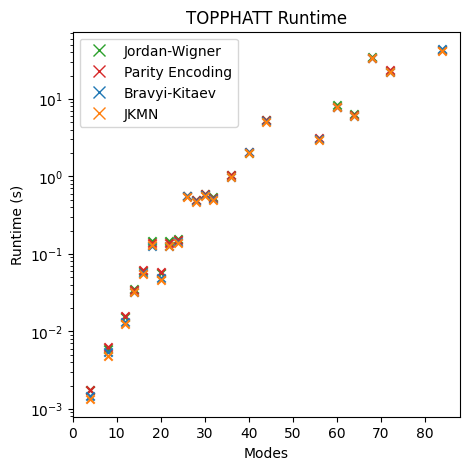

In [22]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
# from matplotlib.colors import 
ffig, ax = plt.subplots(figsize=(5,5))
# colors = iter(cm.d)

for n, grp in timings_df.groupby("molname"):
    ax.scatter(x = "n_modes", y = "JW", data=grp, marker="x", color="tab:green")
    ax.scatter(x = "n_modes", y = "Parity", data=grp,marker="x",color="tab:red")
    ax.scatter(x = "n_modes", y = "BK", data=grp, marker="x",color="tab:blue")
    ax.scatter(x = "n_modes", y = "JKMN", data=grp, marker="x",color="tab:orange")

handles, labels = plt.gca().get_legend_handles_labels()
# manually define a new patch 
jw_legend = mlines.Line2D([], [], label='Jordan-Wigner', marker="x", linestyle="", color="tab:green", markersize=8)
pe_legend = mlines.Line2D([], [], label='Parity Encoding', marker="x", linestyle="", color="tab:red", markersize=8)
bk_legend = mlines.Line2D([], [], label='Bravyi-Kitaev', marker="x", linestyle="", color="tab:blue", markersize=8)
jkmn_legend = mlines.Line2D([], [], label='JKMN', marker="x", linestyle="", color="tab:orange", markersize=8)
# handles is a list, so append manual patch
handles = [jw_legend,pe_legend,bk_legend, jkmn_legend]


ax.legend(handles=handles)
ax.set_title("TOPPHATT Runtime")
ax.set_yscale("log")
# ax.set_xscale("log")
ax.set_ylabel("Runtime (s)")
ax.set_xlabel("Modes")
plt.show()

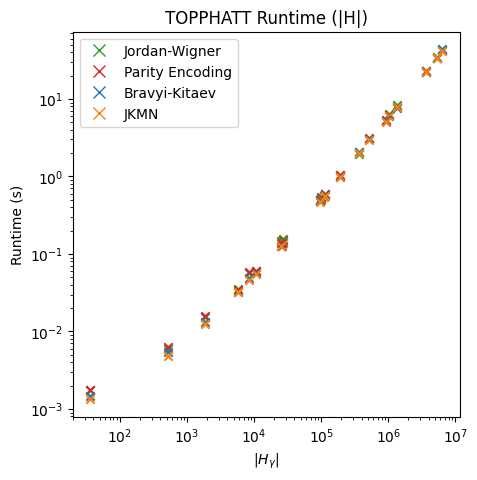

In [33]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5,5))


# ax.plot(np.logspace(1, 7, num=22), func((modes, terms),*popt), linestyle="-" ,color="black")
for n, grp in timings_df.groupby("molname"):
    ax.scatter(x = "n_terms", y = "JW", data=grp, label=n, marker="x", color="tab:green")
    ax.scatter(x = "n_terms", y = "Parity", data=grp, label=n, marker="x",color="tab:red")
    ax.scatter(x = "n_terms", y = "BK", data=grp, label=n, marker="x",color="tab:blue")
    ax.scatter(x = "n_terms", y = "JKMN", data=grp, label=n, marker="x",color="tab:orange")
# ax.legend()
handles, labels = plt.gca().get_legend_handles_labels()
# manually define a new patch 
jw_legend = mlines.Line2D([], [], label='Jordan-Wigner', marker="x", linestyle="", color="tab:green", markersize=8)
pe_legend = mlines.Line2D([], [], label='Parity Encoding', marker="x", linestyle="", color="tab:red", markersize=8)
bk_legend = mlines.Line2D([], [], label='Bravyi-Kitaev', marker="x", linestyle="", color="tab:blue", markersize=8)
jkmn_legend = mlines.Line2D([], [], label='JKMN', marker="x", linestyle="", color="tab:orange", markersize=8)
# handles is a list, so append manual patch
handles = [jw_legend,pe_legend,bk_legend, jkmn_legend]


ax.legend(handles=handles)
ax.set_title("TOPPHATT Runtime (|H|)")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_ylabel("Runtime (s)")
ax.set_xlabel("$|H_{\gamma}|$")
plt.show()

In [1]:
# Import coefficients
import pickle
from ferrmion.encode import TernaryTree
from pathlib import Path

def water_integrals():
    folder = Path.cwd().joinpath(Path("../../../python/tests/"))
    with open(folder.joinpath("./data/water_1e.pkl"), 'rb') as file:
        ones = pickle.load(file)

    with open(folder.joinpath("./data/water_2e.pkl"), 'rb') as file:
        twos = pickle.load(file)
    return (ones, twos)
ones, twos = water_integrals()
twos *= 0.5

In [4]:
from ferrmion.core import topphatt_standard
from ferrmion.optimize import topphatt
from ferrmion.utils import fermionic_to_sparse_majorana
import numpy as np
from copy import deepcopy
import logging
logger = logging.getLogger(__name__)
ones = np.random.random((4,4))
twos = np.random.random((4,4,4,4))

sparse_ham = fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--")))
topphatt(deepcopy(sparse_ham), TernaryTree(4).JordanWigner())

In [ ]:
topphatt_standard("JW", 4,4, ["+-","++--"],[ones, twos])

In [ ]:
topphatt(n_qubits=3, node_map=[(0,(None, None, 1)), (1,(None, None, 2)), (2,(None, None, None))], signatures=["+-", "++--"], coeffs=[ones, twos])

TypeError: topphatt() got an unexpected keyword argument 'node_map'

NameError: name 'Rs' is not defined